# Data Cleaning — Sensores IoT
**Jorge Andrés Mejía — 202300376**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SENSORS = ['temperatura_c', 'presion_psi', 'vibracion_mm_s', 'potencia_kw']

df = pd.read_csv('dataset.csv', sep=';')
print(df.shape)
df.head()

(50, 12)


,id_sensor,fecha_hora,time stamp,inspectedby,maquina_id,temperatura_c,presion_psi,vibracion_mm_s,potencia_kw,estado_operativo,tecnico_responsable,lote_produccion
0,101,1/10/2025 08:23,06/15/2026 18:46:05,auto,M01,85.3,42.1,2.3,15.6,OPERATIVO,Juan Perez,LOT-001
1,102,1/10/2025 08:45,06/15/2026 18:46:05,auto,M01,86.1,43.2,2.4,15.8,OPERATIVO,Juan Perez,LOT-001
2,103,1/10/2025 09:12,06/15/2026 18:46:05,auto,M01,-88.5,41.5,2.3,15.7,MANTENIMIENTO,Juan Perez,LOT-001
3,104,1/10/2025 09:35,06/15/2026 18:46:05,auto,M01,999.0,999.9,99.9,99.9,OPERATIVO,NaN,LOT-001
4,105,1/10/2025 10:05,06/15/2026 18:46:05,inspect,M01,87.2,43.8,2.5,15.9,OPERATIVO,Juan Perez,LOT-002


#### 1. Fechas inválidas
Timestamps con minutos imposibles (`:66:`, `:76:`, etc.) y años erróneos (2035, 2045).

In [17]:
df['time stamp'] = df['time stamp'].str.replace(r'18:[6-9]\d:\d{2}', '18:46:05', regex=True)
df['fecha_hora'] = df['fecha_hora'].str.replace(r'/(2035|2045)\s', '/2025 ', regex=True)
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'], format='%d/%m/%Y %H:%M', errors='coerce')
print('NaT:', df['fecha_hora'].isna().sum())
print(df['fecha_hora'].agg(['min', 'max']))

NaT: 0
min   2025-10-01 08:23:00
max   2025-10-02 04:55:00
Name: fecha_hora, dtype: datetime64[ns]


#### 2. Valores faltantes
`"null"`, `"N/A"` y celdas vacías en maquina_id, técnico y temperatura.

In [18]:
df.replace(['null', 'N/A', '', ' '], np.nan, inplace=True)
for col in SENSORS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

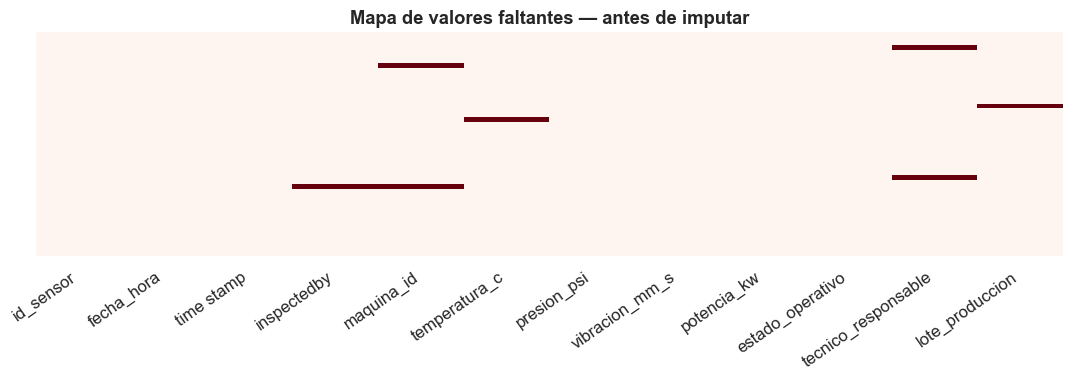

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds', yticklabels=False, ax=ax)
ax.set_title('Mapa de valores faltantes — antes de imputar', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [20]:
df['maquina_id'] = df['maquina_id'].fillna(method='ffill')
for col in ['tecnico_responsable', 'lote_produccion']:
    df[col] = df.groupby('maquina_id')[col].transform(lambda x: x.ffill().bfill())
df['temperatura_c'] = df.groupby('maquina_id')['temperatura_c'].transform(lambda x: x.fillna(x.median()))
print('Nulos tras imputación:', df.isnull().sum().sum())

Nulos tras imputación: 1


#### 3. Outliers extremos
Valores sentinel: 999, 10000000, -5555555, -99.9. Se reemplazan por mediana de la máquina.

In [21]:
df_raw = df[SENSORS].copy()

RANGES = {
    'temperatura_c':  (30, 150),
    'presion_psi':    (10, 100),
    'vibracion_mm_s': (0, 20),
    'potencia_kw':    (0.5, 50),
}

for col, (lo, hi) in RANGES.items():
    mask = (df[col] < lo) | (df[col] > hi)
    print(f'{col}: {mask.sum()} outliers')
    df.loc[mask, col] = np.nan

for col in RANGES:
    df[col] = df.groupby('maquina_id')[col].transform(lambda x: x.fillna(x.median()))

temperatura_c: 6 outliers
presion_psi: 3 outliers
vibracion_mm_s: 5 outliers
potencia_kw: 3 outliers


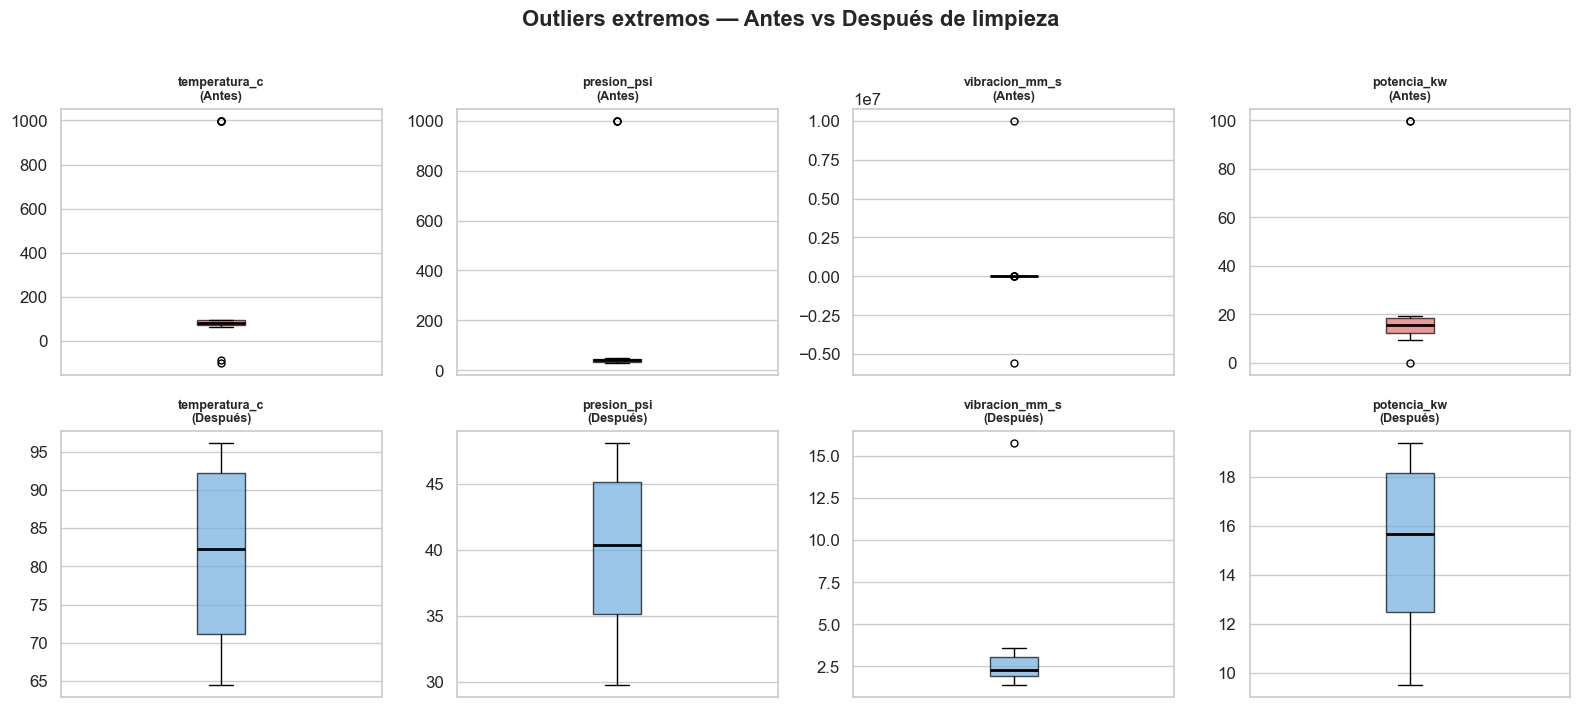

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
colors = ['#e07070', '#70b0e0']

for i, col in enumerate(SENSORS):
    for j, (data, label, color) in enumerate(zip([df_raw[col], df[col]], ['Antes', 'Después'], colors)):
        ax = axes[j][i]
        ax.boxplot(data.dropna(), patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.7),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', color='red', markersize=5))
        ax.set_title(f'{col}\n({label})', fontsize=9, fontweight='bold')
        ax.set_xticks([])

plt.suptitle('Outliers extremos — Antes vs Después de limpieza', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### 4. maquina_id con valor erróneo
`M04D` en lugar de `M04`.

In [23]:
df['maquina_id'] = df['maquina_id'].str.replace(r'(M\d{2})[^\d].*', r'\1', regex=True)
print(sorted(df['maquina_id'].unique()))

['M01', 'M02', 'M03', 'M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10', 'M11', 'M12']


#### 5. Técnico responsable inválido
`"zzzzzzzz"` — basura de entrada.

In [24]:
mask = df['tecnico_responsable'].str.fullmatch(r'[a-zA-ZáéíóúÁÉÍÓÚñÑ ]+', na=False) == False
df.loc[mask, 'tecnico_responsable'] = np.nan
df['tecnico_responsable'] = df.groupby('maquina_id')['tecnico_responsable'].transform(lambda x: x.ffill().bfill())

#### 6. lote_produccion inconsistente
`LOTx001`, `LOT/001` → `LOT-001`.

In [25]:
df['lote_produccion'] = df['lote_produccion'].str.replace(r'LOT[^0-9]*(\d+)', r'LOT-\1', regex=True)

#### 7. Duplicados semánticos
Misma máquina con la misma fecha_hora.

In [26]:
antes = len(df)
df = df.sort_values(['maquina_id', 'fecha_hora']).drop_duplicates(subset=['maquina_id', 'fecha_hora'], keep='first')
print(f'Eliminados: {antes - len(df)} | Filas finales: {len(df)}')

Eliminados: 0 | Filas finales: 50


#### 8. Valores fuera de rango físico
`potencia_kw = 0.0001` — imposible para una máquina industrial. Cubierto por los rangos del paso 3.

In [27]:
print(df[SENSORS].describe())

       temperatura_c  presion_psi  vibracion_mm_s  potencia_kw
count      50.000000    50.000000       50.000000    50.000000
mean       81.473000    39.918000        2.708000    14.942000
std        10.402066     5.719139        2.011355     3.216053
min        64.500000    29.800000        1.400000     9.500000
25%        71.225000    35.125000        1.925000    12.500000
50%        82.300000    40.350000        2.300000    15.650000
75%        92.175000    45.150000        3.075000    18.175000
max        96.200000    48.100000       15.800000    19.400000


---
#### Dataset limpio — Exportar y visualizar

In [28]:
df = df.reset_index(drop=True)
print(f'Shape final: {df.shape} | Nulos: {df.isnull().sum().sum()}')
df.to_csv('dataset_limpio.csv', index=False)

Shape final: (50, 12) | Nulos: 1


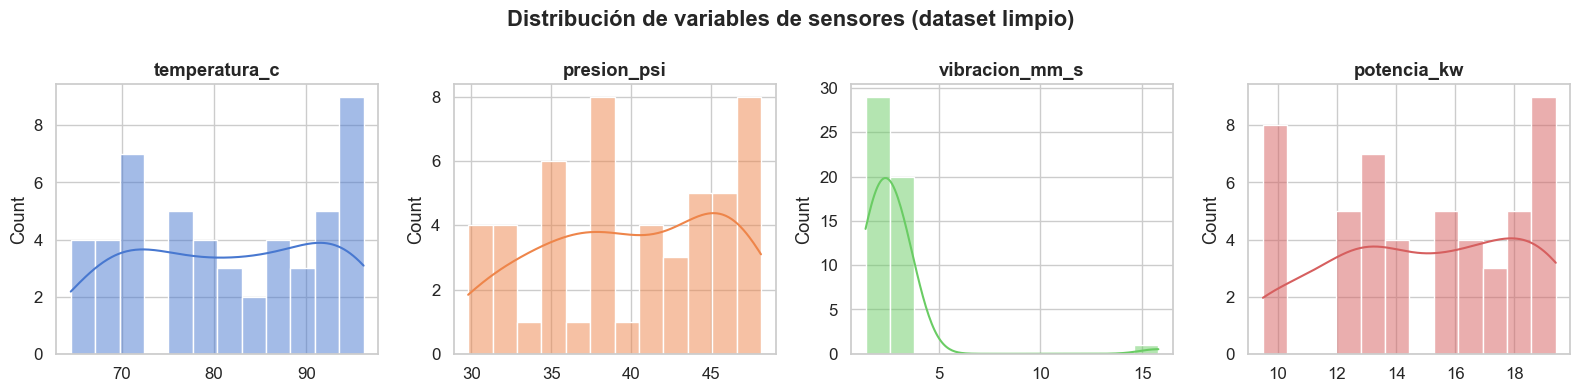

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = sns.color_palette('muted', 4)

for ax, col, color in zip(axes, SENSORS, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=12)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Distribución de variables de sensores (dataset limpio)', fontweight='bold')
plt.tight_layout()
plt.show()

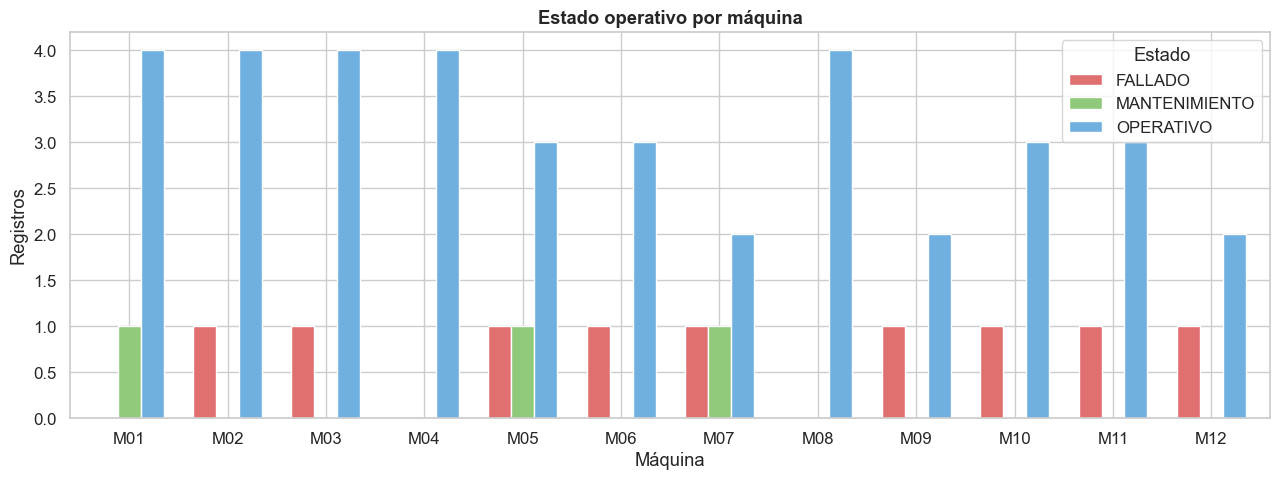

In [30]:
pivot = df.groupby(['maquina_id', 'estado_operativo']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind='bar', ax=ax, color=['#e07070', '#90c97a', '#70b0e0'], edgecolor='white', width=0.7)
ax.set_title('Estado operativo por máquina', fontweight='bold')
ax.set_xlabel('Máquina')
ax.set_ylabel('Registros')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Estado')
plt.tight_layout()
plt.show()

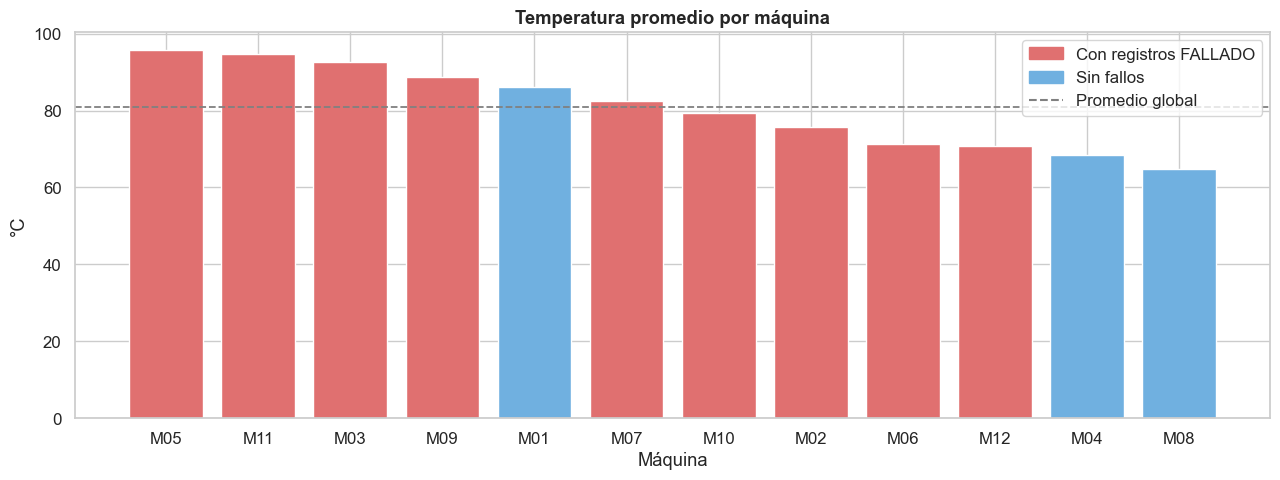

In [31]:
temp_mean = df.groupby('maquina_id')['temperatura_c'].mean().sort_values(ascending=False)
falladas = df[df['estado_operativo'] == 'FALLADO']['maquina_id'].unique()

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ['#e07070' if m in falladas else '#70b0e0' for m in temp_mean.index]
ax.bar(temp_mean.index, temp_mean.values, color=bar_colors, edgecolor='white')
ax.axhline(temp_mean.mean(), color='gray', linestyle='--', linewidth=1.3, label='Promedio global')
ax.set_title('Temperatura promedio por máquina', fontweight='bold')
ax.set_ylabel('°C')
ax.set_xlabel('Máquina')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e07070', label='Con registros FALLADO'),
    Patch(color='#70b0e0', label='Sin fallos'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Promedio global')
])
plt.tight_layout()
plt.show()

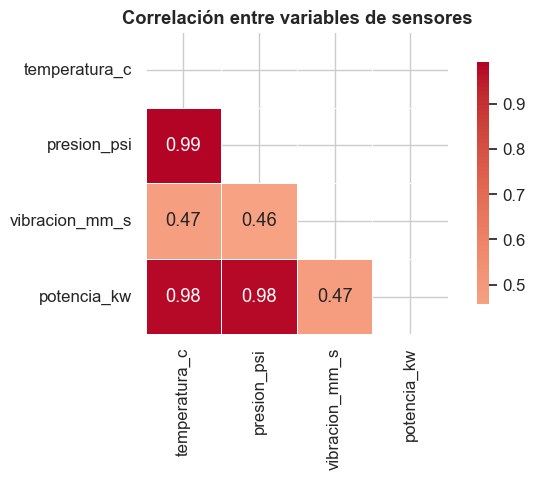

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[SENSORS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre variables de sensores', fontweight='bold')
plt.tight_layout()
plt.show()

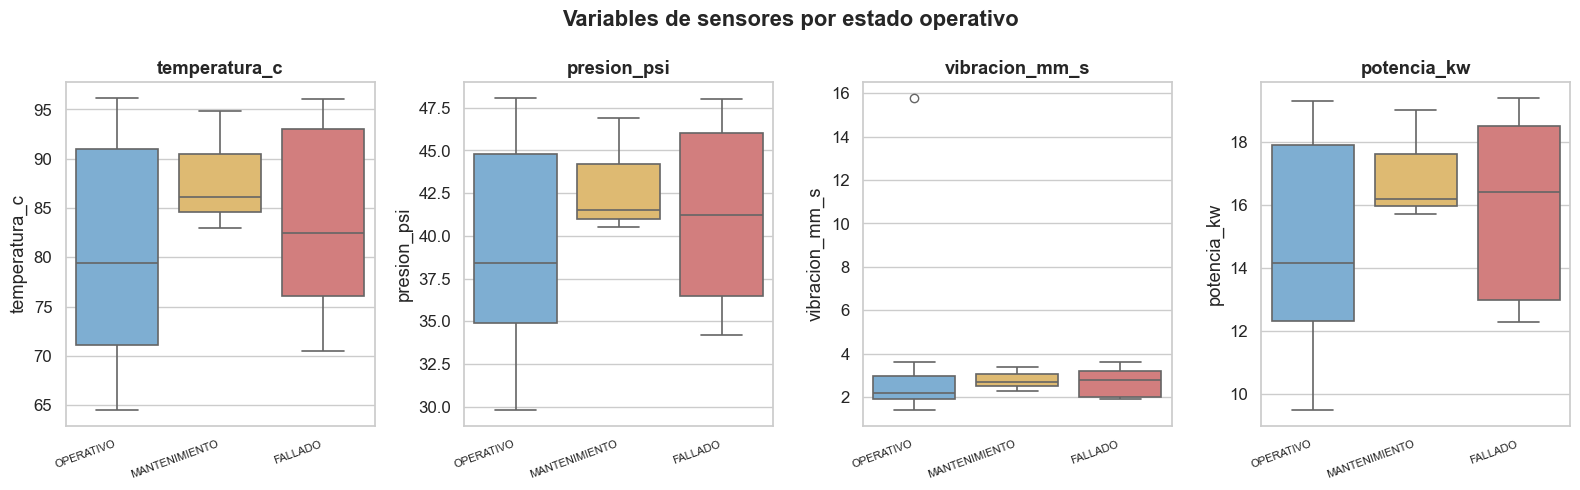

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
palette = {'OPERATIVO': '#70b0e0', 'MANTENIMIENTO': '#f0c060', 'FALLADO': '#e07070'}
order = ['OPERATIVO', 'MANTENIMIENTO', 'FALLADO']

for ax, col in zip(axes, SENSORS):
    sns.boxplot(data=df, x='estado_operativo', y=col, order=order,
                palette=palette, ax=ax, linewidth=1.2)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(order, rotation=20, ha='right', fontsize=8)

plt.suptitle('Variables de sensores por estado operativo', fontweight='bold')
plt.tight_layout()
plt.show()